In [3]:
# Load the processed dataset for exploratory analysis
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
data_path = project_root / "data" / "processed" / "model_data.csv"

df = pd.read_csv(data_path, parse_dates=["date"])

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

df.head()

Shape: (3607, 9)
Date range: 2016-11-09 00:00:00 to 2026-09-24 00:00:00


,date,pm25,temperature,humidity,rainfall,wind_speed,fire_count,total_frp,mean_frp
0,2016-11-09,270.0,21.7,51,0.0,9.5,4052.0,32329.46,7.978643
1,2016-11-10,259.0,21.0,59,0.0,7.1,3169.0,17701.61,5.585866
2,2016-11-11,274.0,21.0,64,0.0,7.4,4339.0,32915.66,7.586001
3,2016-11-12,238.0,21.7,60,0.0,7.6,2280.0,15017.25,6.586513
4,2016-11-13,175.0,21.9,58,0.0,4.9,1195.0,7370.45,6.167741


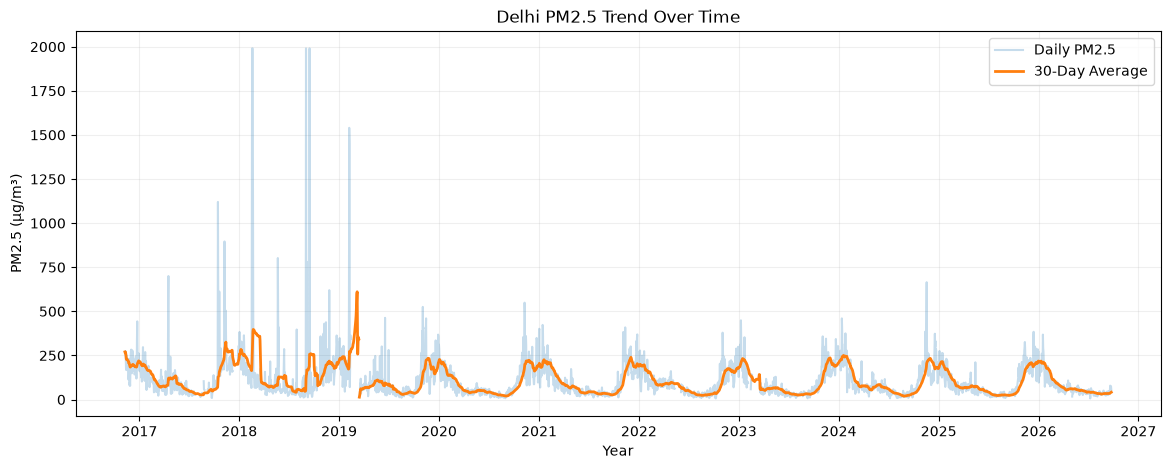

In [4]:
# Visualize daily PM2.5 and its 30-day trend
df["pm25_30d_avg"] = df["pm25"].rolling(
    window=30,
    min_periods=1
).mean()

plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["pm25"],
    alpha=0.25,
    label="Daily PM2.5"
)

plt.plot(
    df["date"],
    df["pm25_30d_avg"],
    linewidth=2,
    label="30-Day Average"
)

plt.title("Delhi PM2.5 Trend Over Time")
plt.xlabel("Year")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

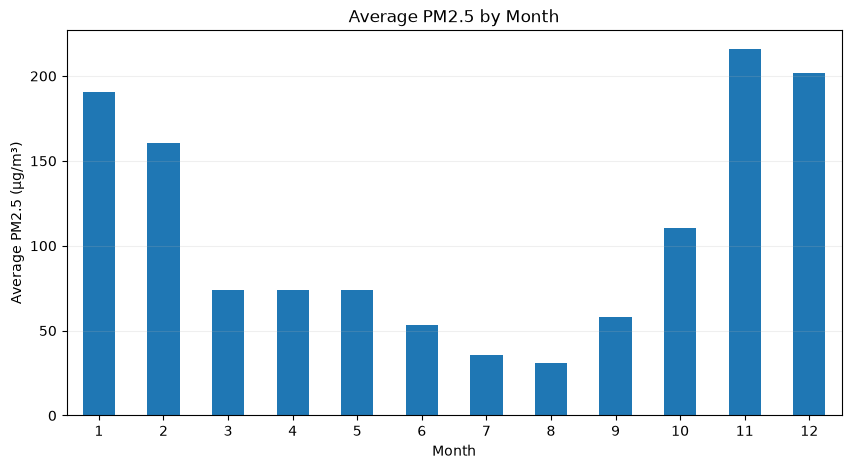

In [5]:
# Compare average PM2.5 across months
df["month"] = df["date"].dt.month

monthly_pm25 = df.groupby("month")["pm25"].mean()

plt.figure(figsize=(10, 5))
monthly_pm25.plot(kind="bar")

plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)

plt.show()

In [6]:
# Check how weather variables are associated with PM2.5
weather_corr = df[
    ["pm25", "temperature", "humidity", "rainfall", "wind_speed"]
].corr()["pm25"].sort_values(ascending=False)

print("Correlation with PM2.5:")
print(weather_corr)

Correlation with PM2.5:
pm25           1.000000
humidity       0.046097
rainfall      -0.135824
wind_speed    -0.149403
temperature   -0.427135
Name: pm25, dtype: float64


In [7]:
# Compare daily regional fire activity with PM2.5
fire_analysis = df.dropna(subset=["pm25", "fire_count"]).copy()

fire_corr = fire_analysis[
    ["pm25", "fire_count", "total_frp", "mean_frp"]
].corr()["pm25"].sort_values(ascending=False)

print("Correlation with PM2.5:")
print(fire_corr)

Correlation with PM2.5:
pm25          1.000000
fire_count    0.201115
total_frp     0.193792
mean_frp      0.118120
Name: pm25, dtype: float64


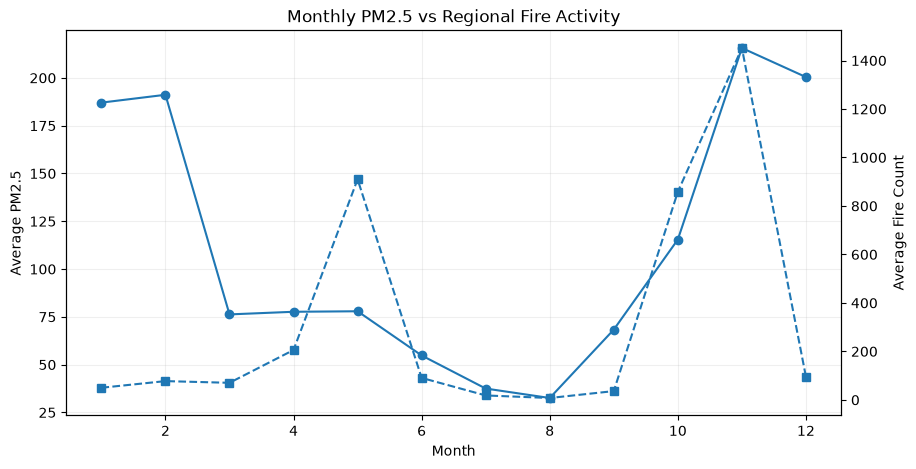

In [8]:
# Compare monthly patterns of fire activity and PM2.5
monthly_pattern = (
    fire_analysis
    .assign(month=fire_analysis["date"].dt.month)
    .groupby("month")
    .agg(
        avg_pm25=("pm25", "mean"),
        avg_fire_count=("fire_count", "mean")
    )
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    monthly_pattern.index,
    monthly_pattern["avg_pm25"],
    marker="o",
    label="PM2.5"
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Average PM2.5")

ax2 = ax1.twinx()
ax2.plot(
    monthly_pattern.index,
    monthly_pattern["avg_fire_count"],
    marker="s",
    linestyle="--",
    label="Fire Count"
)
ax2.set_ylabel("Average Fire Count")

plt.title("Monthly PM2.5 vs Regional Fire Activity")
ax1.grid(alpha=0.2)

plt.show()

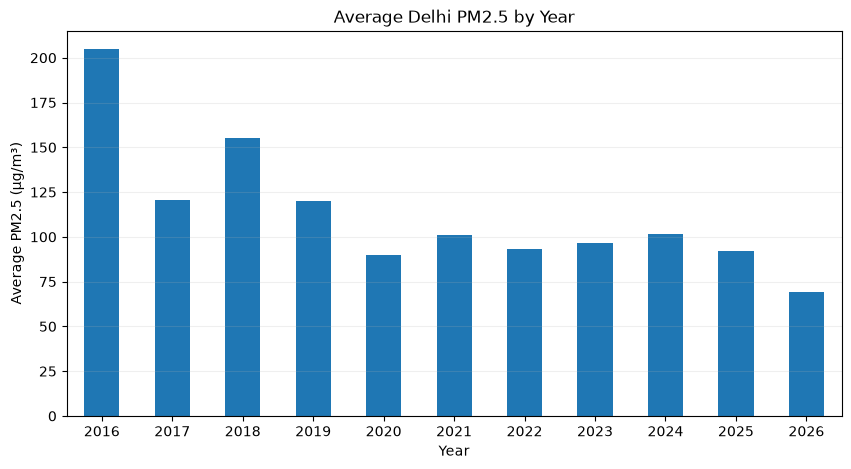

In [9]:
# Check how average PM2.5 changes across years
yearly_pm25 = (
    df.assign(year=df["date"].dt.year)
      .groupby("year")["pm25"]
      .mean()
)

plt.figure(figsize=(10, 5))
yearly_pm25.plot(kind="bar")

plt.title("Average Delhi PM2.5 by Year")
plt.xlabel("Year")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)

plt.show()

In [10]:
# Inspect unusually high PM2.5 readings before deciding how to handle them
extreme_pm25 = (
    df[df["pm25"] > 500]
    [["date", "pm25"]]
    .sort_values("pm25", ascending=False)
)

print("Readings above 500:", len(extreme_pm25))

extreme_pm25.head(15)

Readings above 500: 27


,date,pm25
465,2018-02-17,1990.0
467,2018-02-19,1990.0
466,2018-02-18,1990.0
675,2018-09-15,1990.0
662,2018-09-02,1990.0
820,2019-02-07,1540.0
821,2019-02-08,1450.0
340,2017-10-15,1120.0
468,2018-02-20,1080.0
364,2017-11-08,896.0


In [11]:
# Inspect PM2.5 values around the most extreme readings
extreme_dates = df.loc[df["pm25"] > 1000, "date"]

extreme_context = df[
    df["date"].isin(
        pd.DatetimeIndex(extreme_dates).union(
            extreme_dates - pd.Timedelta(days=1)
        ).union(
            extreme_dates + pd.Timedelta(days=1)
        )
    )
][["date", "pm25"]].sort_values("date")

extreme_context

,date,pm25
339,2017-10-14,114.0
340,2017-10-15,1120.0
341,2017-10-16,695.0
464,2018-02-16,871.0
465,2018-02-17,1990.0
466,2018-02-18,1990.0
467,2018-02-19,1990.0
468,2018-02-20,1080.0
469,2018-02-21,513.0
661,2018-09-01,178.0


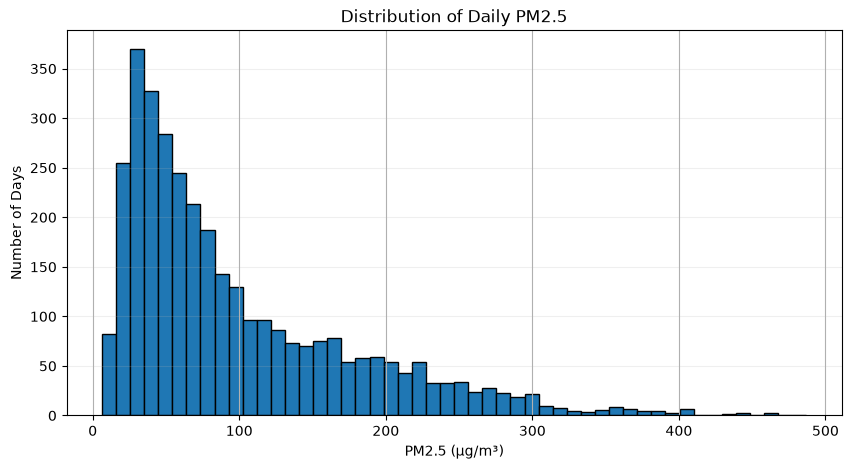

In [12]:
# Visualize the normal PM2.5 distribution without extreme values dominating the chart
plt.figure(figsize=(10, 5))

df.loc[df["pm25"] <= 500, "pm25"].hist(
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Daily PM2.5")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Number of Days")
plt.grid(axis="y", alpha=0.2)

plt.show()

In [13]:
# Quantify the upper tail of the PM2.5 distribution
percentiles = df["pm25"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
)

print(percentiles)

0.500      71.25
0.750     141.00
0.900     223.00
0.950     275.00
0.990     443.00
0.995     617.80
1.000    1990.00
Name: pm25, dtype: float64


In [14]:
# Summarize the main patterns discovered during EDA
highest_month = monthly_pm25.idxmax()
lowest_month = monthly_pm25.idxmin()

print("Highest pollution month:", highest_month)
print("Lowest pollution month:", lowest_month)
print("PM2.5 vs temperature:", round(weather_corr["temperature"], 3))
print("PM2.5 vs wind speed:", round(weather_corr["wind_speed"], 3))
print("PM2.5 vs rainfall:", round(weather_corr["rainfall"], 3))
print("PM2.5 vs fire count:", round(fire_corr["fire_count"], 3))
print("PM2.5 readings above 500:", len(extreme_pm25))

Highest pollution month: 11
Lowest pollution month: 8
PM2.5 vs temperature: -0.427
PM2.5 vs wind speed: -0.149
PM2.5 vs rainfall: -0.136
PM2.5 vs fire count: 0.201
PM2.5 readings above 500: 27
